# 02 — Реалистичная ёмкость + слиппедж → правдоподобный абсолют

В 01 абсолют (CAGR 186%, DCA 4.36×) был оптимистичен: 2%-реинвест × ~10.8k сделок,
бесконечная ёмкость, нулевой слиппедж на микрокапах. Здесь приземляем:

1. **Ёмкость:** на сделку нельзя поставить больше, чем `PART_CAP` доля dollar-
   volume монеты за окно набора (≈30 мин). Сверх — обрезаем.
2. **Market-impact слиппедж:** доп. кост = SPREAD + IMPACT·(ордер / ликвидность окна).
   Чем больше ордер относительно объёма — тем дороже (квадрат масштаба бьёт по росту).
3. **Стена масштабирования:** свипуем стартовый капитал → видим, как CAGR падает,
   когда ордера упираются в ликвидность.

Стримы — честные из 01 (pump vol-gate+классификатор, dump price-step, оба со
стоп −20% + KS). Ликвидность = медианный dollar-volume/мин за день до входа.

In [1]:
import sys; sys.path.insert(0,".")
from _lab import *
import numpy as np, pandas as pd
from pathlib import Path
import heapq
from sklearn.ensemble import HistGradientBoostingRegressor
WIN=15;H=240;COOLDOWN=10;N_MAX=10;FEE=0.00075;DELTA=0.02;DAY=1440
THR_D=0.07; THR_P=0.05; VOL_MULT=3.0
FEATN=["r1","r3","r5","r15","r30","r60","accel","surge15","surge1","volreg","rng15","hi_d","lo_d","streak"]
def clusters(c,thr,side):
    if len(c)<WIN+5: return []
    r=np.full(len(c),np.nan); r[WIN:]=c[WIN:]/c[:-WIN]-1
    cond=(r<=-thr) if side<0 else (r>=thr); out=[];i=WIN;n=len(c)
    while i<n:
        if not cond[i] or (i>0 and cond[i-1]): i+=1;continue
        st=i;lt=i;f=0;j=i+1
        while j<n:
            if cond[j]: lt=j;f=0
            else:
                f+=1
                if f>=COOLDOWN: break
            j+=1
        out.append((st,lt)); i=lt+COOLDOWN+1
    return out
def fills(c,st,en,side):
    pos=[st];lc=c[st];t=st+1
    while t<=en and len(pos)<N_MAX:
        trig=(c[t]<=lc*(1-DELTA)) if side<0 else (c[t]>=lc*(1+DELTA))
        if trig: pos.append(t);lc=c[t]
        t+=1
    return pos
def feat(c,v,h,l,st,side):
    def ret(k): return c[st]/c[st-k]-1 if st-k>=0 else np.nan
    base=np.median(v[max(0,st-DAY):st]) if st>60 else np.nan
    lr=np.diff(np.log(c[max(0,st-60):st+1]))
    surge15=v[st-14:st+1].sum()/(base*15) if base and base>0 else np.nan
    s=0;k=st
    if side<0:
        while k>0 and c[k]<c[k-1]: s+=1;k-=1
    else:
        while k>0 and c[k]>c[k-1]: s+=1;k-=1
    return [ret(1),ret(3),ret(5),ret(15),ret(30),ret(60),
            (c[st]/c[st-5]-1)-(c[st-5]/c[st-15]-1 if st-15>=0 else np.nan),
            surge15, v[st]/base if base and base>0 else np.nan,
            lr.std() if len(lr)>5 else np.nan,
            (h[st-14:st+1].max()-l[st-14:st+1].min())/c[st],
            c[st]/h[max(0,st-DAY):st+1].max()-1, c[st]/l[max(0,st-DAY):st+1].min()-1, s], surge15

In [2]:
def build():
    D=[];P=[]
    for sym in list_symbols():
        try: df=ohlcv(sym,"2024-01-01","2026-07-01","1min")
        except Exception: continue
        c=df["close"].to_numpy("float64");v=df["volume"].to_numpy("float64")
        h=df["high"].to_numpy("float64");l=df["low"].to_numpy("float64");ts=df.index;n=len(c)
        dv=c*v
        for side,thr,store,gate in [(-1,THR_D,D,False),(+1,THR_P,P,True)]:
            for (st,en) in clusters(c,thr,side):
                ex=en+1+H
                if st<DAY or st+1>=n or ex>=n: continue
                f,surge15=feat(c,v,h,l,st,side)
                if gate and not (surge15>=VOL_MULT): continue
                pos=[p for p in fills(c,st,en,side) if p+1<n]
                pr=np.array([c[p+1] for p in pos]);ws=np.arange(1,len(pr)+1,dtype=float);ws/=ws.sum()
                avg=(ws*pr).sum(); raw=c[ex]/avg-1
                pnl=(raw if side<0 else -raw)-2*FEE
                seg=c[en+1:ex+1]; mae=(seg.min()/avg-1) if side<0 else -(seg.max()/avg-1)
                liq=np.median(dv[max(0,st-DAY):st])    # $/min liquidity
                store.append(dict(entry=ts[st+1],exit_ts=ts[ex],pnl=pnl,mae=mae,liq=liq,
                                  **{FEATN[i]:f[i] for i in range(len(FEATN))}))
    return pd.DataFrame(D),pd.DataFrame(P)
DUMP,PUMP=build()
for nm,X in [("DUMP",DUMP),("PUMP",PUMP)]:
    X.sort_values("entry",inplace=True);X.reset_index(drop=True,inplace=True)
    print(f"{nm}: {len(X)} trades, median liq ${X.liq.median():,.0f}/min")

DUMP: 4361 trades, median liq $2,671/min
PUMP: 12034 trades, median liq $3,139/min


In [3]:
def wf(X):
    X=X.dropna().reset_index(drop=True)
    et=X.entry.values.astype("datetime64[ns]").astype("int64");w=15*60*10**9
    X["breadth"]=np.arange(len(et))-np.searchsorted(et,et-w,side="right")+1
    pred=np.full(len(X),np.nan); cuts=[int(len(X)*q) for q in (0.40,0.55,0.70,0.85,1.0)];prev=cuts[0]
    for cut in cuts[1:]:
        tr=X.iloc[:prev]
        m=HistGradientBoostingRegressor(max_depth=3,learning_rate=0.05,max_iter=300,
            l2_regularization=1.0,min_samples_leaf=40,random_state=0)
        m.fit(tr[FEATN],tr.pnl);pred[prev:cut]=m.predict(X.iloc[prev:cut][FEATN]);prev=cut
    X["pred"]=pred; return X
DUMP=wf(DUMP);PUMP=wf(PUMP)
STOP=0.20;KS=40
def layers(X):
    pnl=np.where(X.mae.values<=-STOP,-STOP-2*FEE,X.pnl.values)
    keep=((X.pred.values>0)|np.isnan(X.pred.values))&(X.breadth.values<=KS)&(X.liq.values>0)
    Y=X.copy();Y["bpnl"]=pnl;return Y[keep].reset_index(drop=True)
BOTH=pd.concat([layers(DUMP),layers(PUMP)]).sort_values("entry").reset_index(drop=True)
print("combined tradable events:",len(BOTH))

combined tradable events: 10799


In [4]:
# realistic portfolio: capacity cap + market-impact slippage
FILL_MIN=30; PART_CAP=0.10; SPREAD=0.0010; IMPACT=0.10; MAX=50
def realbook(df,start,f=0.02,dca=0.0):
    df=df.sort_values("entry"); en=df.entry.values.astype("datetime64[ns]")
    ex=df.exit_ts.values.astype("datetime64[ns]"); bpnl=df.bpnl.values; liq=df.liq.values
    cap_notional=PART_CAP*liq*FILL_MIN     # max $ deployable per trade
    cash=start;dep=0.;openh=[];eq_t=[];eq_v=[];taken=0;capped=0;slip_tot=0.;contrib=start
    months=list(pd.date_range(pd.Timestamp(en.min()).normalize().replace(day=1),pd.Timestamp(ex.max()),freq="MS")) if dca>0 else []
    mi=0
    for i in range(len(bpnl)):
        now=pd.Timestamp(en[i])
        while mi<len(months) and months[mi]<=now: cash+=dca;contrib+=dca;eq_t.append(months[mi]);eq_v.append(cash+dep);mi+=1
        while openh and openh[0][0]<=en[i]:
            _,notional,pn=heapq.heappop(openh);cash+=notional*(1+pn);dep-=notional;eq_t.append(pd.Timestamp(_));eq_v.append(cash+dep)
        eq=cash+dep; desired=f*eq
        notional=min(desired,cap_notional[i])
        if notional>desired-1e-9: pass
        else: capped+=1
        if len(openh)<MAX and cash>=notional and notional>1:
            part=notional/(liq[i]*FILL_MIN); slip=SPREAD+IMPACT*part
            slip_tot+=notional*slip
            cash-=notional;dep+=notional;heapq.heappush(openh,(ex[i],notional,bpnl[i]-slip));taken+=1
    while mi<len(months): cash+=dca;contrib+=dca;eq_t.append(months[mi]);eq_v.append(cash+dep);mi+=1
    for _,notional,pn in sorted(openh): cash+=notional*(1+pn);dep-=notional;eq_t.append(pd.Timestamp(_));eq_v.append(cash+dep)
    s=pd.Series(eq_v,index=pd.to_datetime(eq_t)).sort_index();s=s[~s.index.duplicated(keep="last")].resample("1D").last().ffill()
    return s,cash,contrib,taken,capped,slip_tot
def stats(s,start):
    r=s.pct_change().dropna();span=(s.index[-1]-s.index[0]).days/365.25
    sh=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan
    peak=np.maximum.accumulate(s.values);dd=(s.values/peak-1).min()
    return (s.iloc[-1]/start)**(1/span)-1, sh, dd
print(f"model: fill window {FILL_MIN}m, participation cap {PART_CAP:.0%} of $vol, "
      f"slippage = {SPREAD*1e4:.0f}bp + {IMPACT:.2f}*participation")
print(f"\n=== SCALING WALL: same strategy, different START capital (compound 2%) ===")
print(f"{'start':>10}{'CAGR':>9}{'Sharpe':>8}{'maxDD':>8}{'% capped':>10}{'slip drag':>11}")
for start in (1_000,10_000,50_000,200_000,1_000_000):
    s,fin,_,tk,cap,slip=realbook(BOTH,start)
    cg,sh,dd=stats(s,start)
    print(f"${start:>9,.0f}{cg*100:>+8.1f}%{sh:>8.2f}{dd*100:>7.1f}%{cap/tk*100:>9.1f}%  ${slip:>9,.0f}")

model: fill window 30m, participation cap 10% of $vol, slippage = 10bp + 0.10*participation

=== SCALING WALL: same strategy, different START capital (compound 2%) ===
     start     CAGR  Sharpe   maxDD  % capped  slip drag
$    1,000  +140.4%    4.34   -9.5%      4.1%  $    1,092


$   10,000   +99.1%    3.53   -9.8%     13.7%  $   12,017
$   50,000   +64.3%    2.74   -9.5%     27.0%  $   56,650


$  200,000   +36.4%    2.04  -11.4%     44.8%  $  196,264
$1,000,000   +11.6%    0.99  -13.5%     68.7%  $  744,353


=== DCA $100/month, REALISTIC (capacity + slippage) ===
  contributed:        $2,800
  FINAL robot value:  $9,064   (optimistic 01 was $12,205)
  profit on money in: +224%   (3.24x contributions)
  slippage paid:      $1,056   |  trades capacity-capped: 4%


[saved] notebooks\pump_dump_combined\_out\comb_02_realistic_dca.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_02_realistic_dca.png')

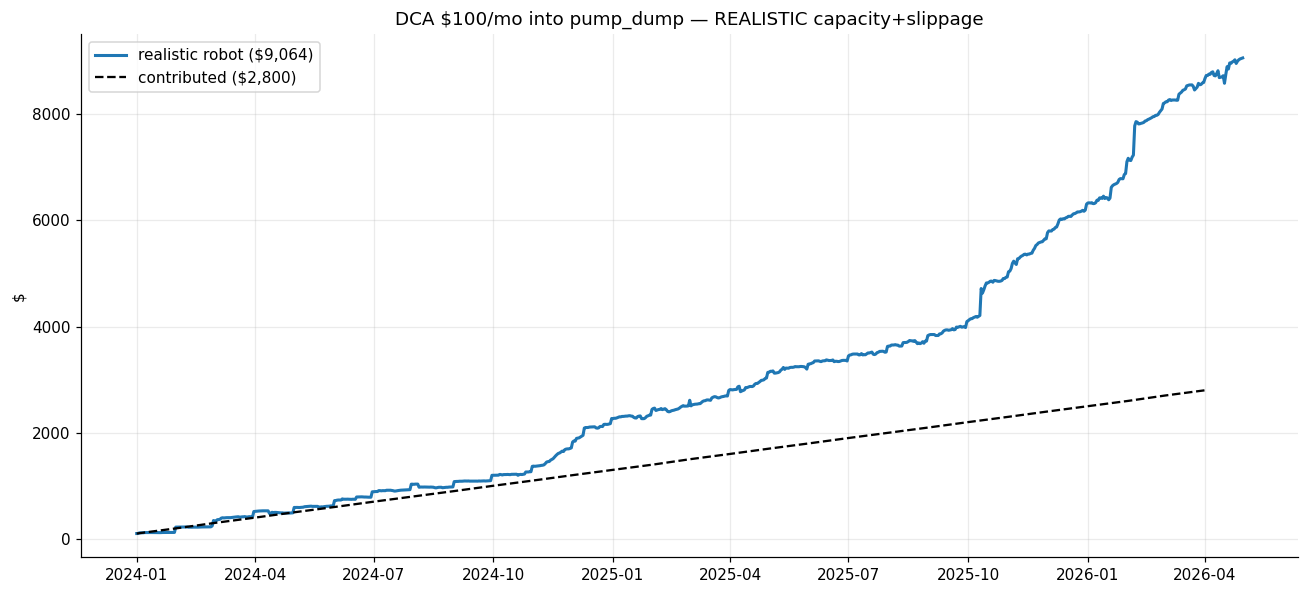

In [5]:
# DCA $100/month under realistic constraints
s,fin,contrib,tk,cap,slip=realbook(BOTH,0.0,f=0.02,dca=100.0)
print("=== DCA $100/month, REALISTIC (capacity + slippage) ===")
print(f"  contributed:        ${contrib:,.0f}")
print(f"  FINAL robot value:  ${fin:,.0f}   (optimistic 01 was $12,205)")
print(f"  profit on money in: {(fin/contrib-1)*100:+.0f}%   ({fin/contrib:.2f}x contributions)")
print(f"  slippage paid:      ${slip:,.0f}   |  trades capacity-capped: {cap/tk*100:.0f}%")
# also a small fixed-size sanity (no compound) for reference
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5.5))
months=pd.date_range(s.index.min().replace(day=1),s.index.max(),freq="MS")
contrib_line=pd.Series([100*(i+1) for i in range(len(months))],index=months)
plt.plot(s.index,s.values,color="#1f77b4",lw=2,label=f"realistic robot (${fin:,.0f})")
plt.plot(contrib_line.index,contrib_line.values,"k--",label=f"contributed (${contrib:,.0f})")
plt.title("DCA $100/mo into pump_dump — REALISTIC capacity+slippage");plt.ylabel("$");plt.legend()
show("comb_02_realistic_dca")

## Как читать
- **Стена масштабирования** — при малом счёте ($1k) ордера крошечные, ёмкость/слиппедж
  почти не мешают → CAGR близок к оптимистичному. С ростом старта ордера упираются в
  ликвидность микрокапов: растёт % обрезанных сделок и слиппедж, CAGR ПАДАЕТ. Это и есть
  реальный потолок — стратегия не масштабируется на большие деньги.
- **DCA реалистичный** — правдоподобная стоимость робота к 2026 (ниже оптимистичных $12.2k).
- Параметры слиппеджа (PART_CAP, IMPACT) — оценочные; абсолют всё ещё in-sample и без
  live-подтверждения, но порядок величины уже честный.

*Verdict после прогона.*

## VERDICT (combined 02)

**Главное — СТЕНА МАСШТАБИРОВАНИЯ.** Медианная ликвидность монет ~$2.7-3.1k/мин
(тонкие микрокапы). Один combined-стрим, реинвест 2%, разный старт:
$1k→CAGR140%/Sh4.34, $10k→99%/3.53, $50k→64%/2.74, $200k→36%/2.04,
**$1M→11.6%/Sh0.99 (69% сделок обрезано об ликвидность, $744k слиппеджа).**
Стратегия НЕ масштабируется — нишевая, для малого капитала. (Ровно почему такой
edge не арбитражится крупными деньгами.)

**DCA $100/мес реалистично:** $2800 внесено → робот **$9,064** к 2026 (3.24×,
+224%), vs оптимистичные $12,205 в 01. Счёт остаётся мал → ёмкость почти не жмёт
(4% обрезано), DCA в режиме малого счёта.

**Честно:** стена масштабирования и DCA-форма робастны. Но абсолют ($1k/140%/Sh4.3)
— in-sample потолок: параметры слиппеджа (PART_CAP 10%, IMPACT 0.10) оценочные,
латентность/филлы не моделированы, pump-классификатор тонкий, live=0. Порядок
величины честный; реальное будет ниже.

**Дальше:** анти-overfit пампа; чувствительность к slippage-параметрам; порт в
strategies/бота с малым сайзингом и дефолт-он tail-лимитами.